# Interpolation polynomiale - Étude du phénomène de Runge

### Importation de packages pour Python

In [96]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as npl
from scipy import interpolate

## Retour sur le phénomène de Runge

On a vu dans le cours le phénomène de Runge qui se traduit par une mauvaise interpolation, lorsque l'on augmente le degré du polynôme d'interpolation de Lagrange, de la fonction $f$ définie sur $\mathbb{R}$ par
$$
f(x) = \dfrac{1}{\alpha^2+x^2}, \; \alpha >0.
$$
Le but du TP est d'observer ce phénomène mais aussi de mettre en oeuvre une meilleure répartition des points d'interpolation à l'aide des racines des polynômes de Chebyshev et de constater l'atténuation du phénomène de Runge. Plus particulièrement, vous implémenterez des fonctions permettant de calculer le polynôme d'interpolation de Lagrange par la méthode directe. L'interpolation par la méthode de Lagrange et celle de Newton vous est ensuite donnée. Enfin, à partir de la méthode de Newton, vous ferez l'interpolation en utilisant les points de Chebyshev.

### Fonction de Runge

>**À faire :** Implémenter une fonction **Runge** qui à un vecteur $x$ sous format numpy retourne le vecteur $f(x)$. Puis, tracer de cette fonction sur l'intervalle $[-3,3]$.

In [144]:
alpha=5
def Runge(x):
    x = np.array(x)
    return 1 / (alpha**2 + x**2)

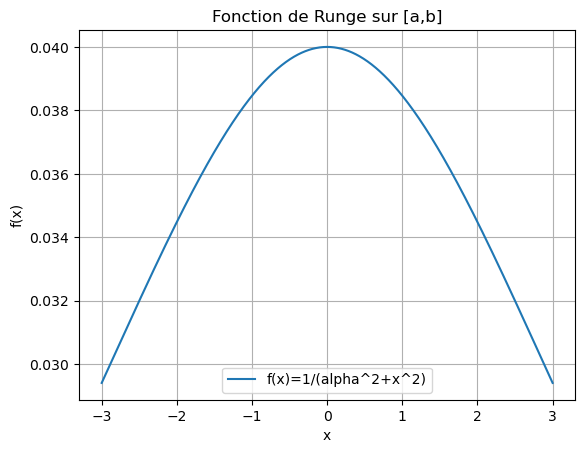

In [145]:
a=-3
b=3
x = np.linspace(-3, 3, 1000)
y = Runge(x)
plt.figure()
plt.plot(x, y, label="f(x)=1/(alpha^2+x^2)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Fonction de Runge sur [a,b]")
plt.grid(True)
plt.legend()
plt.show()

### Construction de points d'interpolation équirépartis

Dans un premier temps, nous allons considérer des points d'interpolation uniformément répartis sur l'intervalle d'interpolation $[a,b]$, $a<b$. L'ensemble des points d'interpolation $(x_j)_{0\leq j\leq n}$ va donc être donné, pour un certain $n\geq 1$, par
$$ x_j = a + (b-a)\frac j n, \quad 0\leq j\leq n.$$


>**À faire :** Implémenter une fonction **Interp_Equi** qui prend en arguments d'entrée les valeurs $a$ et $b$ (qui définissent l'intervalle d'interpolation) ainsi que $m$ de manière à retourner un vecteur $x$ de $m$ points d'interpolations équirépartis sur $[a,b]$. 

In [146]:
def Interp_Equi(a, b, n):
    """
    Retourne le vecteur x de n+1 points équirépartis sur [a,b].
    """
    return np.linspace(a, b, n + 1)


### Méthode directe de construction d'un polynôme d'interpolation

On rappelle que la méthode directe de construction consiste à simplement poser le système d'équations suivant
$$ p(x_j) = y_j, \quad 0\leq j\leq n,$$
sous la forme d'un système linéaire dont la solution correspond au vecteur $(a_j)_{0\leq j\leq n}$ de coefficients du polynôme d'interpolation. Plus précisément, le système s'écrit
$$ \left[ 
\begin{array}{ccccc}
1 & x_0 & \cdots & x_0^{n-1} & x_0^n \\ 
1  & x_1 & \cdots & x_1^{n-1}  & x_1^n \\ 
\vdots & \vdots &  & & \vdots \\ 
1 & x_n & \cdots & x_{n}^{n-1} & x_{n}^n
\end{array}
\right]\left[\begin{array}{c}a_0\\ a_1\\ \vdots \\ a_n \end{array}\right] = \left[\begin{array}{c}y_0\\ y_1\\ \vdots \\ y_n \end{array}\right].
 $$
 
 >**À faire :** Implémenter une fonction **Vandermonde** qui prend en arguments d'entrée un vecteur $x$ de points d'interpolation et qui rend, en sortie, la matrice de Vandermonde associée au système linéaire précédent. 

In [147]:
def Vandermonde(x):
    """
    Construit la matrice de Vandermonde V telle que V[i,j] = x[i]**j.
    Si x contient n points, V est de taille (n, n).
    """
    x = np.array(x)
    n = x.size
    return np.vander(x, N=n, increasing=True)

In [148]:
Vandermonde([2,3,4])

array([[ 1,  2,  4],
       [ 1,  3,  9],
       [ 1,  4, 16]])

 >**À faire :** À l'aide de la fonction **npl.solve**, implémenter une fonction **Methode_directe** qui prend en argument les points d'interpolations $x$ ainsi qu'une fonction $f$ à interpoler et qui rend en sortie un vecteur $a$ qui contient les coefficients du polynôme d'interpolation de $f$ aux points $x$.

In [149]:
def Methode_directe(x, f):
    """
    Renvoie les coefficients a du polynôme d'interpolation p(x)=a0+a1 x+...+a_m x^m
    interpolant f aux points x.
    """
    x = np.array(x)
    V = Vandermonde(x)
    y = f(x)  # vecteur des valeurs f(x_i)
    a = npl.solve(V, y)
    return a

 >**À faire :** Grâce aux fonctions **PtsInterp_Equi** et **Methode_directe**, tracer sur une même figure la fonction **Runge** sur l'intervalle $[-3,3]$ ainsi que son polynôme d'interpolation pour $5$, $10$ et $15$ points d'interpolation.

In [150]:
def eval_poly(a, x):
    # Horner adapté à a = [a0, a1, ..., a_m]
    y=0
    for k in range(len(a)-1, -1, -1):
        y = y*x + a[k]
    return y

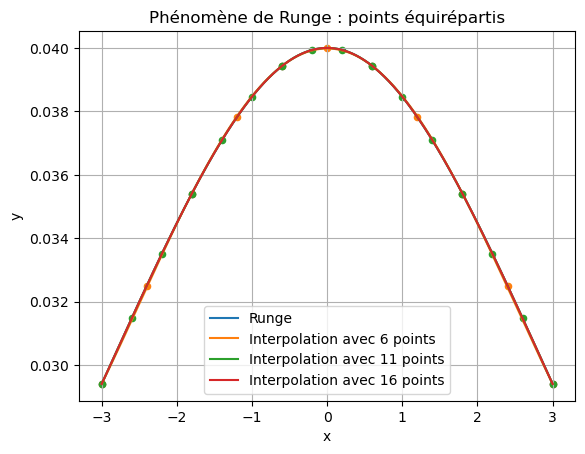

In [151]:
a, b = -3, 3
xx = np.linspace(a, b, 2000)
ms = [5,10,15]  # <-- mettez ici les 3 valeurs de m demandées (m+1 points)
plt.figure()
plt.plot(xx, Runge(xx), label="Runge")
for m in ms:
    xk = Interp_Equi(a, b, m)
    ak = Methode_directe(xk, Runge)
    pk = eval_poly(ak, xx)
    plt.plot(xx, pk, label=f"Interpolation avec {m+1} points")
    plt.scatter(xk, Runge(xk), s=20)  # points d'interpolation
plt.xlabel("x")
plt.ylabel("y")
plt.title("Phénomène de Runge : points équirépartis")
plt.grid(True)
plt.legend()
plt.show()

### Méthode de Lagrange

Nous avons vu dans le cours que le polynôme d'interpolation de Lagrange peut être calculé par la méthode de Lagrange. Cette méthode consiste à trouver une base de polynômes, qui sont les polynômes de Lagrange, dans laquelle on exprime le polynôme d'interpolation. Étant donné une fonction $f$ et un ensemble $(x_j)_{0\leq j\leq n}$ de points d'interpolation, le polynôme d'interpolation $p$ s'exprime comme
$$
p(x) = \sum_{j = 0}^{n} f(x_j) L_{j,n}(x), \quad \forall x \in \mathbb{R},
$$
avec $(L_{j,n})_{0\leq j\leq n}$ la base de polynôme de Lagrange donnée par
$$
L_{j,n}(x) = \prod_{\substack{k = 0\\k\neq j}}^{n} \dfrac{x-x_k}{x_j-x_k}.
$$

 >**À faire :** Écrire une fonction **Methode_Lagrange** qui implémente la méthode précédente avec en arguments d'entrée un vecteur $x\_interp$ de points d'interpolation et un vecteur $x$ de points d'abscisse. Cette fonction returnera la matrice $L$ dont chaque colonne correspond au vecteur $\ell_i = L_{i,n}(x)$. 
 
On obtient alors le vecteur  $y = p(x)$ grâce au produit matrice-vecteur $y = Lz$ où $z = f(x\_interp)$. Le produit matrice-vecteur peut se faire grâce à la fonction **np.dot**.

In [152]:
def Methode_Lagrange(x_interp,x):
    m = len(x_interp)
    n = len(x)
    L = np.ones((n,m))
    for i in range(m):
        for j in range(m):
            if j != i:
                L[:,i] = L[:,i]*(x - x_interp[j])/(x_interp[i] - x_interp[j])
    return L

 >**À faire :** Tracer ensuite sur une même figure la fonction **Runge** sur l'intervalle $[-3,3]$ ainsi que son polynôme d'interpolation obtenue avec la méthode de Lagrange pour $5$, $10$ et $15$ points d'interpolation.

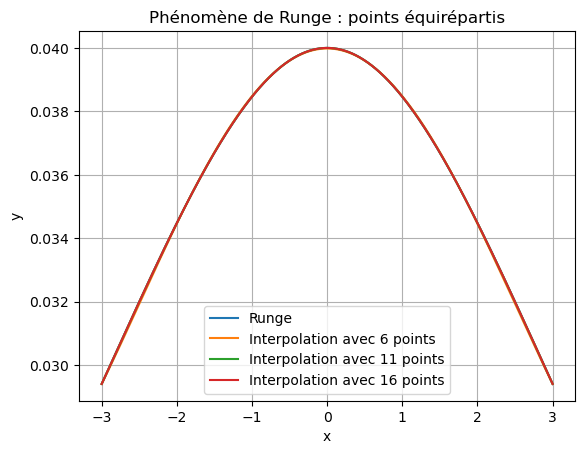

In [153]:
x = np.linspace(-3,3,1000)
plt.plot(x,Runge(x), label="Runge")
for n in [5,10,15]:
    x_interp = Interp_Equi(-3,3,n)
    z = Runge(x_interp)
    L = Methode_Lagrange(x_interp,x)
    P = L.dot(z)
    plt.plot(x,P,label=f"Interpolation avec {n+1} points")    
plt.xlabel("x")
plt.ylabel("y")
plt.title("Phénomène de Runge : points équirépartis")
plt.grid(True)
plt.legend()
plt.show()    

### Méthode de Newton

La méthode de Newton, comme pour celle de Lagrange, permet d'exprimer le polynôme d'interpolation de Lagrange dans une base de polynômes, qui sont les polynômes de Newton. Étant donné une fonction $f$ et un ensemble $(x_j)_{0\leq j\leq n}$ de points d'interpolation, le polynôme d'interpolation $p$ s'exprime comme
$$
p(x) = \sum_{j = 0}^{n} z_j N_{j,n}(x), \quad \forall x \in \mathbb{R},
$$
avec $(N_{j,n})_{0\leq j\leq n}$ la base de polynôme de Newton donnée par
$$
N_{j,n}(x) = \prod_{k = 0}^{j} (x-x_k),
$$
et $(z_j)_{0\leq j\leq n}$ les coefficients qui sont solution du système triangulaire
$$
\left[ 
\begin{array}{cccccc}
1 & 0 & 0  &  \cdots & 0 \\ 
1  & (x_1-x_0) & 0  & \cdots   & 0 \\ 
1  & (x_2-x_0) & (x_2-x_0)(x_2-x_1) & \ddots   & \vdots \\ 
\vdots & \vdots &  \vdots  & \ddots & 0 \\ 
1 & (x_n-x_0) &  (x_n-x_0)(x_n-x_1) & \cdots & \prod_{j = 0}^{n-1}(x_n-x_j)
\end{array}
\right]\left[\begin{array}{c}z_0\\ z_1\\ \vdots \\ z_n \end{array}\right] = \left[\begin{array}{c}y_0\\ y_1\\ \vdots \\ y_n \end{array}\right].
$$

 >**À faire :** Écrire une fonction **Methode_Newton** qui implémente la méthode précédente avec en arguments d'entrée un vecteur $x\_interp$ de points d'interpolation et un vecteur $x$ de points d'abscisse. Cette fonction returnera la matrice $N$ dont chaque colonne correspond au vecteur $n_i = N_{i,n}(x)$. 

In [154]:
def Methode_Newton(x_interp,x):
    m = len(x_interp)
    n = len(x)
    N = np.ones((n,m))
    for i in range(m):
        for j in range(i):
            N[:,i] = N[:,i]*(x - x_interp[j])
    return N

>**À faire :** Écrire une fonction **Coeff_Newton** qui permet de calculer les coefficients $(z_j)_{0\leq j\leq n}$ en résolvant le système triangulaire inférieur par un algorithme de descente. Cette fonction prendra en entrée le vecteur $x\_interp$ des points d'interpolation ainsi que la fonction $f$ à interpoler et rendra le vecteur $z$ des coefficients.

In [155]:
def Coeff_Newton(x_interp,f):
    m = len(x_interp)
    T = np.zeros((m,m))
    for i in range(m):
        for j in range(m):
            if j == 0:
                T[i,j] = 1
            elif j<=i:
                T[i,j] = T[i,j-1]*(x_interp[i] - x_interp[j-1])
    z = npl.solve(T,f(x_interp))
    return z

On obtient alors le vecteur  $y = p(x)$ grâce au produit matrice-vecteur $y = Lz$.

>**À faire :** Tracer ensuite sur une même figure la fonction **Runge** sur l'intervalle $[-3,3]$ ainsi que son polynôme d'interpolation obtenue avec la méthode de Newton pour $5$, $10$ et $15$ points d'interpolation.

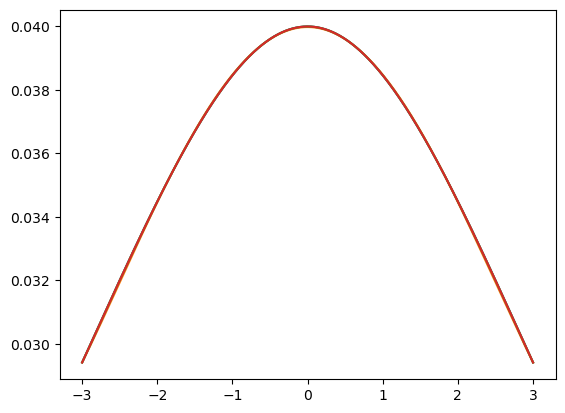

In [156]:
x = np.linspace(-3,3,1000)
plt.plot(x,Runge(x))
for n in [5,10,15]:
    x_interp = Interp_Equi(-3,3,n)
    z = Coeff_Newton(x_interp,Runge)
    N = Methode_Newton(x_interp,x)
    P = N.dot(z)
    plt.plot(x,P)

### Points d'interpolation de Chebyshev

Les points de Chebyshev dans l'intervalle $[-1,1]$ sont donnés par la formule suivante
$$
y_j = \cos\left(\dfrac{2i+1}{2(n+1)}\pi\right), 
\quad 0\leq j\leq n.
$$
Afin d'adapter ces points à un intervalle $[a,b]$, on se basera sur la formule suivante
$$
x_j = \frac{a+b}2 + \frac{a-b}2 y_j,
\quad 0\leq j\leq n.
$$

>**À faire :** Implémenter une fonction **Interp_Chebyshev** qui prend en arguments d'entrée les valeurs $a$ et $b$ (qui définissent l'intervalle d'interpolation) ainsi que $n$ de manière à retourner un vecteur $x$ de $n$ points d'interpolations répartis selon les points de Chebyshev sur $[a,b]$. 

In [157]:

def Interp_Chebyshev(a, b, n):
    """
    Retourne x (m+1 points) de Chebyshev (racines) sur [a,b].
    """
    i = np.arange(n + 1)
    t = np.cos((2*i + 1) * np.pi / (2*(n + 1)))   # points sur [-1,1]
    x = (a + b)/2 + (b - a)/2 * t                 # mapping vers [a,b]
    return x


>**À faire :** Tracer ensuite sur une même figure la fonction **Runge** sur l'intervalle $[-3,3]$ ainsi que son polynôme d'interpolation obtenue avec la méthode de Newton pour $5$, $10$ et $15$ points d'interpolation.

In [158]:
def Newton_coeffs(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = x.size
    dd = y.copy()
    coeffs = np.zeros(n, dtype=float)
    coeffs[0] = dd[0]
    for j in range(1, n):
        dd[:n-j] = (dd[1:n-j+1] - dd[:n-j]) / (x[j:] - x[:n-j])
        coeffs[j] = dd[0]
    return coeffs

In [159]:
def Newton_eval(x_nodes, coeffs, x):
    x_nodes = np.array(x_nodes)
    coeffs = np.array(coeffs)
    x = np.array(x)

    n = coeffs.size
    p = np.zeros_like(x) + coeffs[-1]
    for k in range(n-2, -1, -1):
        p = p * (x - x_nodes[k]) + coeffs[k]
    return p

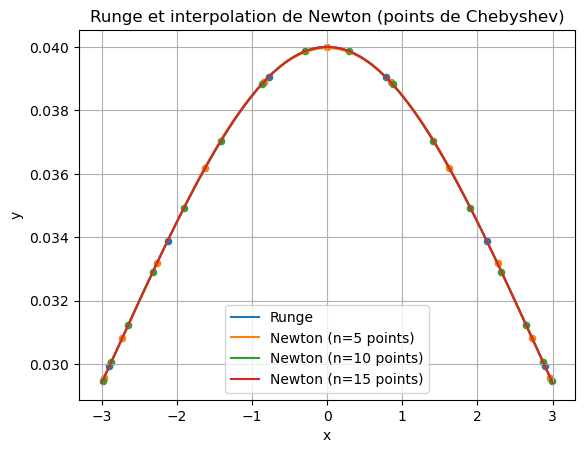

In [160]:
a, b = -3, 3
xx = np.linspace(a, b, 2000)

n_points_list = [5, 10, 15]  # 5, 10, 15 points d'interpolation

plt.figure()
plt.plot(xx, Runge(xx), label="Runge")

for n in n_points_list:
    xk = Interp_Chebyshev(a, b, n)
    yk = Runge(xk)

    ck = Newton_coeffs(xk, yk)          # coeffs Newton
    pk = Newton_eval(xk, ck, xx)        # évaluation

    plt.plot(xx, pk, label=f"Newton (n={n} points)")
    plt.scatter(xk, yk, s=20)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Runge et interpolation de Newton (points de Chebyshev)")
plt.grid(True)
plt.legend()
plt.show()

On peut regrouper les majorations de l’erreur d’interpolation sous la forme
$$
\|f-p_n\|_\infty \;\lesssim\; \frac{\|f^{(n+1)}\|_\infty}{(n+1)!}\left(\frac{b-a}{\lambda}\right)^{n+1},
$$
où $\lambda$ dépend essentiellement du choix des nœuds d’interpolation $(x_i)$ et résume le ``gain'' obtenu sur la taille du polynôme nodal
$\pi_{n+1}(x)=\prod_{i=0}^{n}(x-x_i)$.
En pratique, on retient souvent :
$$
\lambda=1 \quad \text{(nœuds quelconques)},\\
\lambda=e \quad \text{(nœuds équirépartis)},\\
\lambda=4 \quad \text{(nœuds de Chebyshev)}.
$$
Ainsi, plus $\lambda$ est grand, plus la borne décroît vite avec $n$, ce qui explique l’avantage numérique des points de Chebyshev.



**Théorème**

Soit $f:[a,b]\to\mathbb{R}$ une fonction analytique, donnée par une série entière de rayon de convergence $R$
centrée au point $c=\dfrac{a+b}{2}$.
Alors, pour des points d’interpolation $x_{i,n}$ quelconques et $\lambda=1$
(respectivement, pour des points \emph{équidistants} et $\lambda=e$, pour des points de \emph{Tchebychev} et $\lambda=4$),
les polynômes d’interpolation $p_n$ aux points $x_{i,n}$ convergent uniformément vers $f$,
pourvu que
$$
R>\left(\frac{1}{\lambda}+\frac{1}{2}\right)(b-a).
$$


On a ici
$$
f(x)=\frac{1}{\alpha^{2}}\;\frac{1}{1+\left(\frac{x}{\alpha}\right)^{2}}
=\frac{1}{\alpha^{2}}\sum_{k=0}^{+\infty}(-1)^k\left(\frac{x}{\alpha}\right)^{2k}
=\sum_{k=0}^{+\infty}(-1)^k\,\frac{x^{2k}}{\alpha^{2k+2}}.
$$
Cette série entière est centrée en $0$ et admet pour rayon de convergence $R=\alpha$
(car la singularité la plus proche est en $x=\pm i\alpha$).

D’après le théorème cité ci dessus, on en déduit que les polynômes d’interpolation $p_n$
convergent uniformément vers $f$ sur $[a,b]$ dès que
$$
\alpha>\left(\frac{1}{\lambda}+\frac{1}{2}\right)(b-a),
$$
où $\lambda=1$ pour des nœuds quelconques, $\lambda=e$ pour des nœuds équidistants,
et $\lambda=4$ pour des nœuds de Tchebychev.


Avec les paramètres précédents,  $\left(\frac{1}{\lambda}+\frac{1}{2}\right)(b-a) \leq \left(\frac{1}{4}+\frac{1}{2}\right)(b-a)=4.5$,
pour $\alpha =5$, on a que de la convergence uniforme et le phénomène de Runge disparait. 